# Multi-database binary-system survey

For a curated list of 17 binary chemical systems, query **five** materials
databases and compute per-system metrics:

- How many entries exist in each database?
- How many are predicted stable / experimentally synthesised?
- What stoichiometries, space groups, and prototypes are covered?
- Which systems look **underexplored** and worth targeting for new candidates?

**Databases:** Materials Project, AFLOW, JARVIS-DFT, NOMAD, COD

The final output is a ranked CSV saved to `outputs/grand_binary_survey.csv`.

In [1]:
from __future__ import annotations

import os
import pathlib
import warnings

import pandas as pd
from dotenv import load_dotenv
from mp_api.client import MPRester
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=DeprecationWarning)

REPO = pathlib.Path.cwd().parent
OUTPUT_DIR = REPO / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

load_dotenv(REPO / ".env")
API_KEY = "BgwGih6zUKQ93T8xVmVrUZtg4G43DJ30"
    # "Set a real MP_API_KEY in .env (get one at https://next-gen.materialsproject.org/api)"

print(f"REPO = {REPO}")
print(f"Output dir = {OUTPUT_DIR}")

/home/hhoechter/projects/hullgap/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


REPO = /home/hhoechter/projects/hullgap
Output dir = /home/hhoechter/projects/hullgap/outputs


## 1. Define target binary systems

Sorted alphabetically within each pair (MP convention for `chemsys`).

The `microelectronics_tag` column captures domain relevance — silicides and
nitrides are used as contacts/barriers in semiconductor manufacturing.

In [2]:
TARGET_SYSTEMS: list[dict[str, str]] = [
    {"system": "Bi-Co", "tag": ""},
    {"system": "Bi-Fe", "tag": ""},
    {"system": "Bi-Ni", "tag": ""},
    {"system": "Bi-Mn", "tag": ""},
    {"system": "Co-Sb", "tag": ""},
    {"system": "Co-Te", "tag": ""},
    {"system": "Co-Se", "tag": ""},
    {"system": "Bi-Ru", "tag": ""},
    {"system": "Bi-Mo", "tag": ""},
    {"system": "Bi-W",  "tag": ""},
    {"system": "Si-Ti", "tag": "silicide/contact"},
    {"system": "Co-Si", "tag": "silicide/contact"},
    {"system": "Ni-Si", "tag": "silicide/contact"},
    {"system": "Hf-N",  "tag": "nitride/barrier"},
    {"system": "N-Zr",  "tag": "nitride/barrier"},
    {"system": "N-Ta",  "tag": "nitride/barrier"},
    {"system": "N-Ti",  "tag": "nitride/barrier"},
]

def _canonical_chemsys(system: str) -> str:
    """Sort element symbols alphabetically — MP convention."""
    return "-".join(sorted(system.split("-")))

for entry in TARGET_SYSTEMS:
    entry["system"] = _canonical_chemsys(entry["system"])

print(f"{len(TARGET_SYSTEMS)} target systems")
for e in TARGET_SYSTEMS:
    print(f"  {e['system']:>8s}  {e['tag']}")

17 target systems
     Bi-Co  
     Bi-Fe  
     Bi-Ni  
     Bi-Mn  
     Co-Sb  
     Co-Te  
     Co-Se  
     Bi-Ru  
     Bi-Mo  
      Bi-W  
     Si-Ti  silicide/contact
     Co-Si  silicide/contact
     Ni-Si  silicide/contact
      Hf-N  nitride/barrier
      N-Zr  nitride/barrier
      N-Ta  nitride/barrier
      N-Ti  nitride/barrier


## 2. Query the MP summary endpoint

For every binary system, pull all entries with the fields we need.
Results are cached in a dict keyed by chemsys so we can re-run
analysis without re-querying.

In [3]:
FIELDS = [
    "material_id",
    "formula_pretty",
    "composition_reduced",
    "energy_above_hull",
    "formation_energy_per_atom",
    "is_stable",
    "symmetry",
    "structure",
    "nsites",
    "volume",
    "density",
    "band_gap",
]

raw_data: dict[str, list] = {}

with MPRester(API_KEY) as mpr:
    for entry in tqdm(TARGET_SYSTEMS, desc="Querying MP"):
        chemsys = entry["system"]
        docs = mpr.materials.summary.search(
            chemsys=chemsys,
            fields=FIELDS,
        )
        raw_data[chemsys] = docs
        print(f"  {chemsys}: {len(docs)} entries")

print(f"\nTotal entries fetched: {sum(len(v) for v in raw_data.values())}")

Querying MP:   6%|▌         | 1/17 [00:01<00:24,  1.52s/it]

  Bi-Co: 2 entries


Querying MP:  12%|█▏        | 2/17 [00:02<00:17,  1.17s/it]

  Bi-Fe: 0 entries


Querying MP:  18%|█▊        | 3/17 [00:03<00:14,  1.04s/it]

...

  N-Zr: 19 entries


Querying MP:  94%|█████████▍| 16/17 [00:15<00:00,  1.08it/s]

  N-Ta: 28 entries


Querying MP: 100%|██████████| 17/17 [00:16<00:00,  1.05it/s]

  N-Ti: 16 entries

Total entries fetched: 149


## 3. Build per-entry DataFrame

Flatten the API response objects into a single DataFrame for inspection.

In [4]:
rows = []
for chemsys, docs in raw_data.items():
    for doc in docs:
        sym = doc.symmetry
        spg = sym.symbol if sym else None
        spg_number = sym.number if sym else None
        rows.append({
            "chemsys": chemsys,
            "material_id": doc.material_id,
            "formula": doc.formula_pretty,
            "composition_reduced": str(doc.composition_reduced),
            "energy_above_hull": doc.energy_above_hull,
            "formation_energy_per_atom": doc.formation_energy_per_atom,
            "is_stable": doc.is_stable,
            "spacegroup": spg,
            "spacegroup_number": spg_number,
            "nsites": doc.nsites,
            "volume": doc.volume,
            "density": doc.density,
            "band_gap": doc.band_gap,
        })

df_entries = pd.DataFrame(rows)
print(f"{len(df_entries)} total entries across {df_entries['chemsys'].nunique()} systems")
df_entries.head(10)

149 total entries across 14 systems


,chemsys,material_id,formula,composition_reduced,energy_above_hull,formation_energy_per_atom,is_stable,spacegroup,spacegroup_number,nsites,volume,density,band_gap
0,Bi-Co,mp-985280,Co3Bi,Co3 Bi1,0.426736,0.426736,False,I4/mmm,139,4,56.137027,11.411412,0.0
1,Bi-Co,mp-1105522,CoBi3,Co1 Bi3,0.047422,0.047422,False,Pnma,62,16,429.757999,10.600582,0.0
2,Bi-Ni,mp-976799,Ni3Bi,Ni3 Bi1,0.173440,0.173440,False,Pm-3m,221,4,55.830875,11.452591,0.0
3,Bi-Ni,mp-1220533,NiBi,Ni1 Bi1,0.034479,0.034479,False,Cm,8,32,622.208283,11.429814,0.0
4,Bi-Ni,mp-22861,NiBi,Ni1 Bi1,0.302736,0.302736,False,P6_3/mmc,194,4,80.945523,10.982270,0.0
5,Bi-Ni,mp-999318,NiBi,Ni1 Bi1,0.026048,0.026048,False,P6_3/mmc,194,4,77.010060,11.543500,0.0
6,Bi-Ni,mp-23179,NiBi3,Ni1 Bi3,0.036121,0.036121,False,Pnma,62,16,433.717743,10.500129,0.0
7,Bi-Mn,mp-623452,Mn3Bi,Mn3 Bi1,0.393625,0.393625,False,I4/mmm,139,4,68.737196,9.030052,0.0
8,Bi-Mn,mp-669332,Mn3Bi,Mn3 Bi1,0.629964,0.629964,False,R-3m,166,16,311.564154,7.968830,0.0
9,Bi-Mn,mp-1221736,MnBi,Mn1 Bi1,0.218757,0.218757,False,Pmma,51,8,182.037783,9.629801,0.0


## 4. Compute per-system summary metrics

In [5]:
tag_map = {e["system"]: e["tag"] for e in TARGET_SYSTEMS}

summary_rows = []
for chemsys, grp in df_entries.groupby("chemsys"):
    stable = grp[grp["is_stable"] == True]
    unique_stoich = grp["formula"].nunique()
    summary_rows.append({
        "system": chemsys,
        "n_mp_entries": len(grp),
        "n_stable_mp": len(stable),
        "n_unique_stoich": unique_stoich,
        "min_energy_above_hull": grp["energy_above_hull"].min(),
        "stable_formulas": ", ".join(sorted(stable["formula"].unique())) or "(none)",
        "stable_spacegroups": ", ".join(sorted(stable["spacegroup"].dropna().unique())) or "(none)",
        "has_zero_stable_phases": len(stable) == 0,
        "microelectronics_tag": tag_map.get(chemsys, ""),
    })

# Handle systems with zero MP entries (not in df_entries)
queried_systems = set(df_entries["chemsys"].unique())
for entry in TARGET_SYSTEMS:
    chemsys = entry["system"]
    if chemsys not in queried_systems:
        summary_rows.append({
            "system": chemsys,
            "n_mp_entries": 0,
            "n_stable_mp": 0,
            "n_unique_stoich": 0,
            "min_energy_above_hull": None,
            "stable_formulas": "(none)",
            "stable_spacegroups": "(none)",
            "has_zero_stable_phases": True,
            "microelectronics_tag": entry["tag"],
        })

df_summary = pd.DataFrame(summary_rows)
df_summary

,system,n_mp_entries,n_stable_mp,n_unique_stoich,min_energy_above_hull,stable_formulas,stable_spacegroups,has_zero_stable_phases,microelectronics_tag
0,Bi-Co,2,0,2,0.047422,(none),(none),True,
1,Bi-Mn,6,0,3,0.207830,(none),(none),True,
2,Bi-Mo,4,0,4,0.321488,(none),(none),True,
3,Bi-Ni,5,0,3,0.026048,(none),(none),True,
4,Co-Sb,4,1,3,0.000000,CoSb3,Im-3,False,
5,Co-Se,11,2,7,0.000000,"Co3Se4, CoSe2","Fd-3m, Pnnm",False,
6,Co-Si,6,3,5,0.000000,"Co2Si, CoSi, CoSi2","Fm-3m, P2_13, Pnma",False,silicide/contact
7,Co-Te,7,1,5,0.000000,CoTe2,Pnnm,False,
8,Hf-N,16,4,6,0.000000,"Hf2N, Hf3N2, Hf3N4, HfN","Fm-3m, P4_2/mnm, Pnma, R-3m",False,nitride/barrier
9,N-Ta,28,3,9,0.000000,"Ta2N, Ta3N5, TaN","Cmcm, P-31m, P-62m",False,nitride/barrier


## 5. Compute void score

**Void score** ranks systems by how underexplored they are in MP,
weighted by microelectronics relevance.

| Condition | Points |
|-----------|--------|
| 0 MP entries | +3 |
| 1–5 MP entries | +2 |
| 6–15 MP entries | +1 |
| 0 stable phases | +3 |
| ≤ 2 unique stoichiometries | +1 |
| Has microelectronics tag | +1 |

**Caveat**: the emptiest system is not always the best target.
The best targets are sparse in MP but surrounded by chemically
related systems that *do* have stable prototypes (so we can
borrow structural templates for candidate generation).

In [6]:
def compute_void_score(row: pd.Series) -> float:
    score = 0.0

    if row["n_mp_entries"] == 0:
        score += 3.0
    elif row["n_mp_entries"] <= 5:
        score += 2.0
    elif row["n_mp_entries"] <= 15:
        score += 1.0

    if row["n_stable_mp"] == 0:
        score += 3.0

    if row["n_unique_stoich"] <= 2:
        score += 1.0

    if row["microelectronics_tag"]:
        score += 1.0

    return score


df_summary["void_score"] = df_summary.apply(compute_void_score, axis=1)
df_summary = df_summary.sort_values("void_score", ascending=False).reset_index(drop=True)
df_summary

,system,n_mp_entries,n_stable_mp,n_unique_stoich,min_energy_above_hull,stable_formulas,stable_spacegroups,has_zero_stable_phases,microelectronics_tag,void_score
0,Bi-W,0,0,0,NaN,(none),(none),True,,7.0
1,Bi-Ru,0,0,0,NaN,(none),(none),True,,7.0
2,Bi-Fe,0,0,0,NaN,(none),(none),True,,7.0
3,Bi-Co,2,0,2,0.047422,(none),(none),True,,6.0
4,Bi-Mo,4,0,4,0.321488,(none),(none),True,,5.0
5,Bi-Ni,5,0,3,0.026048,(none),(none),True,,5.0
6,Bi-Mn,6,0,3,0.207830,(none),(none),True,,4.0
7,Co-Si,6,3,5,0.000000,"Co2Si, CoSi, CoSi2","Fm-3m, P2_13, Pnma",False,silicide/contact,2.0
8,Co-Sb,4,1,3,0.000000,CoSb3,Im-3,False,,2.0
9,Si-Ti,14,4,7,0.000000,"Ti5Si3, Ti5Si4, TiSi, TiSi2","Cmcm, P4_12_12, P6_3/mcm, Pnma",False,silicide/contact,2.0


## 6. Neighbour-context bonus

A purely empty system may be empty because the chemistry is
genuinely unfavourable. Better targets are sparse themselves but
share an element with systems that *do* have stable compounds.

For each system A-B, count how many *other* queried systems
containing A or B have at least one stable phase. Add a small
bonus proportional to that count.

In [7]:
def _elements(chemsys: str) -> set[str]:
    return set(chemsys.split("-"))


stable_lookup = dict(
    zip(df_summary["system"], df_summary["n_stable_mp"])
)

neighbour_bonus = []
for sys in df_summary["system"]:
    elems = _elements(sys)
    neighbours_with_stable = 0
    for other_sys, n_stable in stable_lookup.items():
        if other_sys == sys:
            continue
        if _elements(other_sys) & elems and n_stable > 0:
            neighbours_with_stable += 1
    neighbour_bonus.append(neighbours_with_stable)

df_summary["neighbour_stable_count"] = neighbour_bonus
df_summary["void_score_adj"] = (
    df_summary["void_score"] + 0.5 * df_summary["neighbour_stable_count"]
)
df_summary = df_summary.sort_values("void_score_adj", ascending=False).reset_index(drop=True)

print("Ranked systems (higher = more interesting):")
df_summary[
    ["system", "n_mp_entries", "n_stable_mp", "n_unique_stoich",
     "has_zero_stable_phases", "microelectronics_tag",
     "void_score", "neighbour_stable_count", "void_score_adj"]
]

Ranked systems (higher = more interesting):


,system,n_mp_entries,n_stable_mp,n_unique_stoich,has_zero_stable_phases,microelectronics_tag,void_score,neighbour_stable_count,void_score_adj
0,Bi-Co,2,0,2,True,,6.0,4,8.0
1,Bi-W,0,0,0,True,,7.0,0,7.0
2,Bi-Ru,0,0,0,True,,7.0,0,7.0
3,Bi-Fe,0,0,0,True,,7.0,0,7.0
4,Bi-Ni,5,0,3,True,,5.0,1,5.5
5,Bi-Mo,4,0,4,True,,5.0,0,5.0
6,Co-Si,6,3,5,False,silicide/contact,2.0,5,4.5
7,Bi-Mn,6,0,3,True,,4.0,0,4.0
8,Co-Sb,4,1,3,False,,2.0,3,3.5
9,Si-Ti,14,4,7,False,silicide/contact,2.0,3,3.5


## 7. Inspect stable phases across all systems

In [8]:
stable_entries = df_entries[df_entries["is_stable"] == True].copy()
stable_entries = stable_entries.sort_values(
    ["chemsys", "formation_energy_per_atom"]
).reset_index(drop=True)

print(f"{len(stable_entries)} stable entries across "
      f"{stable_entries['chemsys'].nunique()} systems\n")

stable_entries[
    ["chemsys", "material_id", "formula", "formation_energy_per_atom",
     "spacegroup", "nsites", "band_gap"]
]

27 stable entries across 10 systems



,chemsys,material_id,formula,formation_energy_per_atom,spacegroup,nsites,band_gap
0,Co-Sb,mp-1317,CoSb3,-0.147884,Im-3,16,0.1633
1,Co-Se,mp-20456,Co3Se4,-0.349812,Fd-3m,14,0.0000
2,Co-Se,mp-20862,CoSe2,-0.345679,Pnnm,6,0.0000
3,Co-Si,mp-7577,CoSi,-0.492925,P2_13,8,0.0000
4,Co-Si,mp-2379,CoSi2,-0.411078,Fm-3m,3,0.0000
5,Co-Si,mp-19905,Co2Si,-0.331056,Pnma,12,0.0000
6,Co-Te,mp-9945,CoTe2,-0.184880,Pnnm,6,0.0000
7,Hf-N,mp-2828,HfN,-1.982478,Fm-3m,2,0.0000
8,Hf-N,mp-776470,Hf3N4,-1.973946,Pnma,28,1.2648
9,Hf-N,mp-1224388,Hf3N2,-1.683427,R-3m,5,0.0000


## 8. Save outputs

In [9]:
csv_path = OUTPUT_DIR / "mp_binary_survey.csv"
df_summary.to_csv(csv_path, index=False)
print(f"Summary saved to {csv_path}")

entries_path = OUTPUT_DIR / "mp_binary_entries.csv"
df_entries.to_csv(entries_path, index=False)
print(f"All entries saved to {entries_path}")

stable_path = OUTPUT_DIR / "mp_binary_stable.csv"
stable_entries.to_csv(stable_path, index=False)
print(f"Stable entries saved to {stable_path}")

Summary saved to /home/hhoechter/projects/hullgap/outputs/mp_binary_survey.csv
All entries saved to /home/hhoechter/projects/hullgap/outputs/mp_binary_entries.csv
Stable entries saved to /home/hhoechter/projects/hullgap/outputs/mp_binary_stable.csv


## 9. Quick visual: void-score ranking

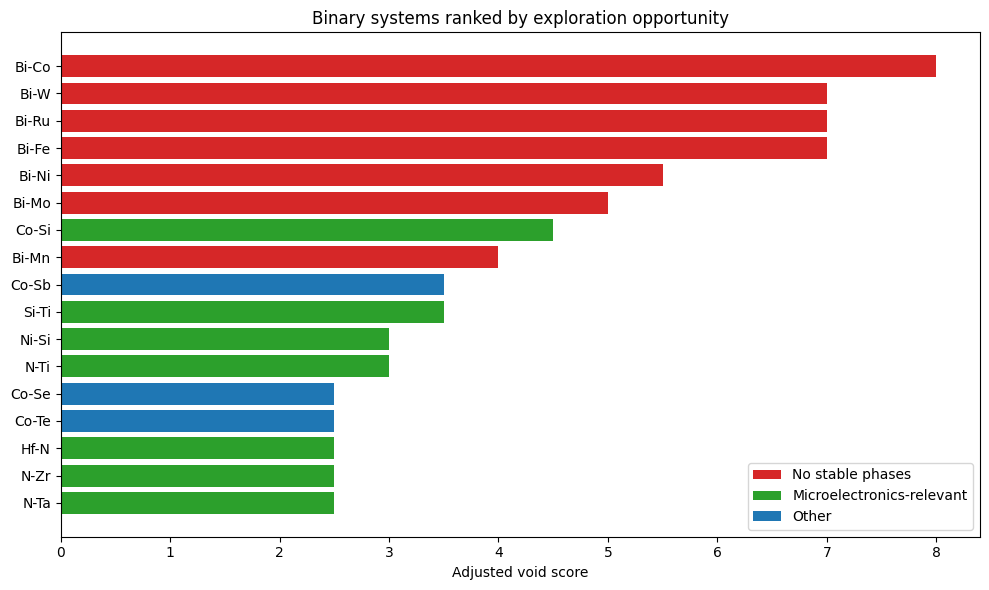

Plot saved to /home/hhoechter/projects/hullgap/outputs/mp_binary_void_scores.png


In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    "#d62728" if z else ("#2ca02c" if tag else "#1f77b4")
    for z, tag in zip(df_summary["has_zero_stable_phases"],
                      df_summary["microelectronics_tag"])
]

bars = ax.barh(df_summary["system"], df_summary["void_score_adj"], color=colors)
ax.set_xlabel("Adjusted void score")
ax.set_title("Binary systems ranked by exploration opportunity")
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#d62728", label="No stable phases"),
    Patch(facecolor="#2ca02c", label="Microelectronics-relevant"),
    Patch(facecolor="#1f77b4", label="Other"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mp_binary_void_scores.png", dpi=150)
plt.show()
print(f"Plot saved to {OUTPUT_DIR / 'mp_binary_void_scores.png'}")

## 10. Stoichiometry coverage heatmap

For each system, show which reduced stoichiometries have entries
and which have stable phases.

In [11]:
stoich_data = []
for chemsys, grp in df_entries.groupby("chemsys"):
    for formula, fgrp in grp.groupby("formula"):
        stoich_data.append({
            "system": chemsys,
            "formula": formula,
            "n_entries": len(fgrp),
            "n_stable": int(fgrp["is_stable"].sum()),
            "min_ehull": fgrp["energy_above_hull"].min(),
        })

df_stoich = pd.DataFrame(stoich_data)
print(f"{len(df_stoich)} unique (system, formula) pairs")
df_stoich.sort_values(["system", "min_ehull"]).head(20)

75 unique (system, formula) pairs


,system,formula,n_entries,n_stable,min_ehull
1,Bi-Co,CoBi3,1,0,0.047422
0,Bi-Co,Co3Bi,1,0,0.426736
3,Bi-Mn,MnBi,3,0,0.207830
2,Bi-Mn,Mn3Bi,2,0,0.393625
4,Bi-Mn,MnBi3,1,0,0.395178
6,Bi-Mo,Bi14Mo5,1,0,0.321488
7,Bi-Mo,Bi3Mo,1,0,0.338744
5,Bi-Mo,Bi10Mo3,1,0,0.348938
8,Bi-Mo,Bi8Mo3,1,0,0.355573
10,Bi-Ni,NiBi,3,0,0.026048


## 11. AFLOW cross-reference

[AFLOW](http://aflow.org) is a second large computational materials database
(~3.5 M entries). Querying it for the same binary systems lets us:

- See which compounds appear in AFLOW but not MP (and vice-versa).
- Get independent formation-energy estimates.
- Identify systems that are sparse in *both* databases (strongest void signal).

We use the AFLUX API (`aflow.org/API/aflux/`) which returns JSON.

> **Note:** OQMD was the original plan but its API has been returning 502
> since at least April 2026. AFLOW is a comparable alternative that is
> currently online.

In [12]:
import requests
import time

AFLOW_BASE = "https://aflow.org/API/aflux/"
AFLOW_PROPS = "enthalpy_formation_atom,Egap,spacegroup_relax,Pearson_symbol_relax,enthalpy_atom"


def query_aflow_system(el_a: str, el_b: str) -> list[dict]:
    """Fetch all AFLOW entries for a binary A-B system via AFLUX."""
    url = (
        f"{AFLOW_BASE}?species({el_a},{el_b}),nspecies(2),"
        f"{AFLOW_PROPS},$paging(0)"
    )
    resp = requests.get(url, timeout=120)
    resp.raise_for_status()
    return resp.json()


aflow_raw: dict[str, list[dict]] = {}

for entry in tqdm(TARGET_SYSTEMS, desc="Querying AFLOW"):
    chemsys = entry["system"]
    el_a, el_b = chemsys.split("-")
    try:
        docs = query_aflow_system(el_a, el_b)
    except Exception as exc:
        print(f"  {chemsys}: FAILED — {exc}")
        docs = []
    aflow_raw[chemsys] = docs
    print(f"  {chemsys}: {len(docs)} entries")
    time.sleep(0.5)

print(f"\nTotal AFLOW entries fetched: {sum(len(v) for v in aflow_raw.values())}")

Querying AFLOW:   0%|          | 0/17 [00:00<?, ?it/s]

  Bi-Co: 216 entries


Querying AFLOW:   6%|▌         | 1/17 [00:02<00:38,  2.38s/it]

  Bi-Fe: 202 entries


Querying AFLOW:  12%|█▏        | 2/17 [00:04<00:34,  2.33s/it]

...

  N-Ta: 164 entries


Querying AFLOW:  94%|█████████▍| 16/17 [00:39<00:02,  2.45s/it]

  N-Ti: 149 entries


Querying AFLOW: 100%|██████████| 17/17 [00:41<00:00,  2.46s/it]


Total AFLOW entries fetched: 3236


### 11a. Build AFLOW entries DataFrame

AFLOW fields:
- `enthalpy_formation_atom` — formation enthalpy per atom (eV/atom).
- `spacegroup_relax` — space group number after relaxation.
- `Pearson_symbol_relax` — Pearson symbol (structure type).

AFLOW doesn't report hull distance directly, so we flag entries with
negative formation enthalpy as potentially stable (confirmed later
when we build the combined hull).

In [13]:
aflow_rows = []
for chemsys, docs in aflow_raw.items():
    for doc in docs:
        hf = doc.get("enthalpy_formation_atom")
        aflow_rows.append({
            "chemsys": chemsys,
            "auid": doc.get("auid"),
            "compound": doc.get("compound"),
            "spacegroup_relax": doc.get("spacegroup_relax"),
            "pearson": doc.get("Pearson_symbol_relax"),
            "enthalpy_formation_atom": hf,
            "enthalpy_atom": doc.get("enthalpy_atom"),
            "band_gap": doc.get("Egap"),
            "neg_formation_energy": (hf is not None and hf < 0),
        })

df_aflow = pd.DataFrame(aflow_rows)
print(f"{len(df_aflow)} AFLOW entries across {df_aflow['chemsys'].nunique()} systems")
df_aflow.head(10)

3236 AFLOW entries across 17 systems


,chemsys,auid,compound,spacegroup_relax,pearson,enthalpy_formation_atom,enthalpy_atom,band_gap,neg_formation_energy
0,Bi-Co,aflow:00bca2b919a0d2ff,Bi2Co4,12,mS12,0.383144,-5.70175,NaN,False
1,Bi-Co,aflow:01a5c2094b788682,Bi4Co4,194,hP8,0.854201,-4.71876,NaN,False
2,Bi-Co,aflow:0304d2b3e06769c3,Bi1Co2,164,hP3,0.495403,-5.58949,NaN,False
3,Bi-Co,aflow:03a15ec7caf10de6,Bi1Co5,12,mS12,0.280492,-6.31633,NaN,False
4,Bi-Co,aflow:0474363050d757b6,Bi6Co10,193,hP16,0.504419,-5.45249,NaN,False
5,Bi-Co,aflow:079b48761cec192d,Bi1Co3,25,oP4,0.503775,-5.83709,NaN,False
6,Bi-Co,aflow:09b590b7d155d814,Bi10Co8,193,hP18,0.557596,-4.84472,NaN,False
7,Bi-Co,aflow:09ddbb5662254e5e,Bi3Co2,166,hR5,0.307647,-4.95815,NaN,False
8,Bi-Co,aflow:0a52f0cf103069cc,Bi3Co9,166,hR4,0.456968,-5.88389,NaN,False
9,Bi-Co,aflow:0a3c3d5565882d03,Bi2Co2,166,hR4,0.508379,-5.06458,NaN,False


### 11b. AFLOW per-system summary

In [14]:
aflow_summary_rows = []
if len(df_aflow) > 0:
    for chemsys, grp in df_aflow.groupby("chemsys"):
        neg_fe = grp[grp["neg_formation_energy"]]
        min_hf = grp["enthalpy_formation_atom"].min() if grp["enthalpy_formation_atom"].notna().any() else None
        aflow_summary_rows.append({
            "system": chemsys,
            "aflow_n_entries": len(grp),
            "aflow_n_neg_fe": len(neg_fe),
            "aflow_n_unique_compounds": grp["compound"].nunique(),
            "aflow_min_hf": min_hf,
            "aflow_neg_fe_compounds": ", ".join(sorted(neg_fe["compound"].unique())) or "(none)",
            "aflow_pearson_types": ", ".join(sorted(grp["pearson"].dropna().unique())) or "(none)",
        })

aflow_systems_seen = {r["system"] for r in aflow_summary_rows}
for entry in TARGET_SYSTEMS:
    chemsys = entry["system"]
    if chemsys not in aflow_systems_seen:
        aflow_summary_rows.append({
            "system": chemsys,
            "aflow_n_entries": 0,
            "aflow_n_neg_fe": 0,
            "aflow_n_unique_compounds": 0,
            "aflow_min_hf": None,
            "aflow_neg_fe_compounds": "(none)",
            "aflow_pearson_types": "(none)",
        })

df_aflow_summary = pd.DataFrame(aflow_summary_rows)
df_aflow_summary

,system,aflow_n_entries,aflow_n_neg_fe,aflow_n_unique_compounds,aflow_min_hf,aflow_neg_fe_compounds,aflow_pearson_types
0,Bi-Co,216,0,47,0.097416,(none),"cF12, cF16, cF24, cF32, cF8, cF96, cI40, cP12,..."
1,Bi-Fe,202,0,40,0.188578,(none),"cF12, cF16, cF24, cF32, cF8, cF96, cI40, cP12,..."
2,Bi-Mn,182,0,32,0.188880,(none),"cF12, cF16, cF24, cF32, cF8, cP12, cP2, cP4, c..."
3,Bi-Mo,221,0,46,0.188310,(none),"cF12, cF16, cF24, cF32, cF8, cF96, cI40, cP12,..."
4,Bi-Ni,239,5,49,-0.036368,"Bi12Ni4, Bi2Ni2, Bi4Ni2","cF12, cF16, cF24, cF32, cF8, cF96, cI10, cI40,..."
5,Bi-Ru,200,0,40,0.067154,(none),"cF12, cF16, cF24, cF32, cF8, cF96, cI40, cP12,..."
6,Bi-W,182,0,31,0.343165,(none),"cF12, cF16, cF24, cF32, cP12, cP2, cP4, cP8, h..."
7,Co-Sb,175,49,30,-0.362937,"Co1Sb2, Co1Sb3, Co1Sb5, Co2Sb2, Co2Sb3, Co2Sb4...","cF12, cF16, cF24, cF8, cI10, cI32, cI40, cI58,..."
8,Co-Se,161,38,32,-0.590419,"Co12Se12, Co1Se2, Co1Se3, Co2Se1, Co2Se2, Co2S...","cF12, cF16, cF32, cF56, cF68, cF8, cF96, cI10,..."
9,Co-Si,217,141,46,-1.303080,"Co10Si6, Co10Si8, Co12Si12, Co12Si17, Co12Si4,...","cF12, cF16, cF24, cF32, cF8, cF96, cI10, cI40,..."


## 12. JARVIS-DFT cross-reference

[JARVIS-DFT](https://jarvis.nist.gov/jarvisdft) (NIST) contains ~76 k
DFT entries with formation energies, hull distances, and band gaps.

The live JARVIS API is currently returning 504, so we download the
full `dft_3d` dataset via `jarvis-tools` (FigShare, ~41 MB) and
filter locally for our target binary systems.

In [16]:
from jarvis.db.figshare import data as jdata

jarvis_all = jdata("dft_3d")
print(f"JARVIS dft_3d total entries: {len(jarvis_all)}")

target_elem_sets = {
    entry["system"]: frozenset(entry["system"].split("-"))
    for entry in TARGET_SYSTEMS
}

jarvis_rows = []
for rec in jarvis_all:
    elems = frozenset(rec.get("atoms", {}).get("elements", []))
    if len(elems) != 2:
        continue
    for chemsys, target_elems in target_elem_sets.items():
        if elems == target_elems:
            ehull = rec.get("ehull")
            jarvis_rows.append({
                "chemsys": chemsys,
                "jid": rec.get("jid"),
                "formula": rec.get("formula"),
                "formation_energy_peratom": rec.get("formation_energy_peratom"),
                "ehull": ehull,
                "is_stable": (ehull is not None and ehull <= 0.01),
                "spg_number": rec.get("spg_number"),
                "spg_symbol": rec.get("spg_symbol"),
                "band_gap": rec.get("optb88vdw_bandgap"),
            })
            break

df_jarvis = pd.DataFrame(jarvis_rows)
print(f"{len(df_jarvis)} JARVIS entries across {df_jarvis['chemsys'].nunique()} systems")
df_jarvis.head(10)

Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
JARVIS dft_3d total entries: 75993
131 JARVIS entries across 15 systems


,chemsys,jid,formula,formation_energy_peratom,ehull,is_stable,spg_number,spg_symbol,band_gap
0,Ni-Si,JVASP-90627,SiNi,-0.28064,0.1465,False,198,P2_13,0.000
1,Bi-Co,JVASP-37946,Co3Bi,0.44331,0.4519,False,139,I4/mmm,0.000
2,Co-Te,JVASP-28353,CoTe2,-0.19234,0.0124,False,164,P-3m1,0.000
3,Si-Ti,JVASP-15734,TiSi,-0.69215,0.0000,True,62,Pnma,0.000
4,Bi-Mn,JVASP-5170,MnBi,0.52785,0.5279,False,194,P6_3/mmc,0.000
5,Hf-N,JVASP-15075,HfN,-1.92482,0.0000,True,225,Fm-3m,0.000
6,N-Ta,JVASP-89916,Ta2N,-0.99844,0.0000,True,162,P-31m,0.000
7,N-Ta,JVASP-14878,TaN,-0.98618,0.3344,False,225,Fm-3m,0.000
8,Co-Se,JVASP-12148,CoSe,-0.25744,0.0241,False,129,P4/nmm,0.000
9,N-Zr,JVASP-49777,Zr3N4,-1.71924,0.0238,False,166,R-3m,1.124


### 12a. JARVIS per-system summary

In [17]:
jarvis_summary_rows = []
if len(df_jarvis) > 0:
    for chemsys, grp in df_jarvis.groupby("chemsys"):
        stable = grp[grp["is_stable"]]
        jarvis_summary_rows.append({
            "system": chemsys,
            "jarvis_n_entries": len(grp),
            "jarvis_n_stable": len(stable),
            "jarvis_n_unique_formulas": grp["formula"].nunique(),
            "jarvis_min_ehull": grp["ehull"].min() if grp["ehull"].notna().any() else None,
            "jarvis_stable_formulas": ", ".join(sorted(stable["formula"].unique())) or "(none)",
        })

jarvis_systems_seen = {r["system"] for r in jarvis_summary_rows}
for entry in TARGET_SYSTEMS:
    chemsys = entry["system"]
    if chemsys not in jarvis_systems_seen:
        jarvis_summary_rows.append({
            "system": chemsys,
            "jarvis_n_entries": 0,
            "jarvis_n_stable": 0,
            "jarvis_n_unique_formulas": 0,
            "jarvis_min_ehull": None,
            "jarvis_stable_formulas": "(none)",
        })

df_jarvis_summary = pd.DataFrame(jarvis_summary_rows)
df_jarvis_summary.sort_values("system")

,system,jarvis_n_entries,jarvis_n_stable,jarvis_n_unique_formulas,jarvis_min_ehull,jarvis_stable_formulas
0,Bi-Co,2,0,2,0.0622,(none)
15,Bi-Fe,0,0,0,NaN,(none)
1,Bi-Mn,6,0,3,0.0705,(none)
2,Bi-Mo,2,0,2,0.4689,(none)
3,Bi-Ni,5,2,3,0.0000,"NiBi, NiBi3"
16,Bi-Ru,0,0,0,NaN,(none)
4,Bi-W,2,0,2,0.6262,(none)
5,Co-Sb,4,4,3,0.0000,"CoSb, CoSb2, CoSb3"
6,Co-Se,9,4,4,0.0000,"Co3Se4, Co9Se8, CoSe2"
7,Co-Si,5,3,4,0.0000,"Co2Si, CoSi, CoSi2"


## 13. NOMAD cross-reference

[NOMAD](https://nomad-lab.eu) is a large materials-science data repository.
Many entries originate from AFLOW, OQMD, or MP, but NOMAD also hosts
unique contributed datasets. We query via the NOMAD v1 REST API.

We track the `origin` field so we know which entries are unique to NOMAD
versus re-indexed from databases we already queried.

In [18]:
NOMAD_BASE = "https://nomad-lab.eu/prod/v1/api/v1/entries"
NOMAD_REQUIRED = (
    "include:entry_id,origin,"
    "results.material.chemical_formula_reduced,"
    "results.material.symmetry.space_group_number,"
    "results.material.symmetry.space_group_symbol,"
    "results.material.symmetry.strukturbericht_designation,"
    "results.material.symmetry.prototype_formula"
)
NOMAD_PAGE_SIZE = 100

KNOWN_ORIGINS = {"AFLOW", "OQMD", "Materials Project"}


def query_nomad_system(el_a: str, el_b: str) -> list[dict]:
    """Fetch all NOMAD entries for a binary system with cursor pagination."""
    all_entries: list[dict] = []
    params = {
        "results.material.elements": [el_a, el_b],
        "results.material.n_elements": 2,
        "page_size": NOMAD_PAGE_SIZE,
        "required": NOMAD_REQUIRED,
    }
    url = NOMAD_BASE
    while url:
        resp = requests.get(url, params=params, timeout=60)
        resp.raise_for_status()
        payload = resp.json()
        all_entries.extend(payload.get("data", []))
        url = payload.get("pagination", {}).get("next_page_url")
        params = {}
        time.sleep(0.3)
    return all_entries


nomad_raw: dict[str, list[dict]] = {}

for entry in tqdm(TARGET_SYSTEMS, desc="Querying NOMAD"):
    chemsys = entry["system"]
    el_a, el_b = chemsys.split("-")
    try:
        docs = query_nomad_system(el_a, el_b)
    except Exception as exc:
        print(f"  {chemsys}: FAILED — {exc}")
        docs = []
    nomad_raw[chemsys] = docs
    n_unique = len([d for d in docs if d.get("origin") not in KNOWN_ORIGINS])
    print(f"  {chemsys}: {len(docs)} total, {n_unique} unique-to-NOMAD")

print(f"\nTotal NOMAD entries: {sum(len(v) for v in nomad_raw.values())}")

Querying NOMAD:   6%|▌         | 1/17 [00:09<02:35,  9.73s/it]

  Bi-Co: 563 total, 36 unique-to-NOMAD


Querying NOMAD:  12%|█▏        | 2/17 [00:19<02:23,  9.54s/it]

  Bi-Fe: 498 total, 34 unique-to-NOMAD


Querying NOMAD:  18%|█▊        | 3/17 [00:31<02:29, 10.68s/it]

...

  N-Zr: 421 total, 250 unique-to-NOMAD


Querying NOMAD:  94%|█████████▍| 16/17 [03:17<00:10, 10.77s/it]

  N-Ta: 293 total, 89 unique-to-NOMAD


Querying NOMAD: 100%|██████████| 17/17 [04:07<00:00, 14.56s/it]

  N-Ti: 2533 total, 2352 unique-to-NOMAD

Total NOMAD entries: 11692


### 13a. NOMAD entries DataFrame and per-system summary

In [19]:
nomad_rows = []
for chemsys, docs in nomad_raw.items():
    for doc in docs:
        mat = doc.get("results", {}).get("material", {})
        sym = mat.get("symmetry", {})
        origin = doc.get("origin", "")
        nomad_rows.append({
            "chemsys": chemsys,
            "entry_id": doc.get("entry_id"),
            "origin": origin,
            "formula": mat.get("chemical_formula_reduced"),
            "spg_number": sym.get("space_group_number"),
            "spg_symbol": sym.get("space_group_symbol"),
            "strukturbericht": sym.get("strukturbericht_designation"),
            "prototype_formula": sym.get("prototype_formula"),
            "is_unique_to_nomad": origin not in KNOWN_ORIGINS,
        })

df_nomad = pd.DataFrame(nomad_rows)
print(f"{len(df_nomad)} NOMAD entries, "
      f"{df_nomad['is_unique_to_nomad'].sum()} unique-to-NOMAD")

nomad_summary_rows = []
if len(df_nomad) > 0:
    for chemsys, grp in df_nomad.groupby("chemsys"):
        unique = grp[grp["is_unique_to_nomad"]]
        nomad_summary_rows.append({
            "system": chemsys,
            "nomad_n_total": len(grp),
            "nomad_n_unique": len(unique),
            "nomad_n_unique_formulas": grp["formula"].nunique(),
            "nomad_origins": ", ".join(sorted(grp["origin"].unique())),
            "nomad_prototypes": ", ".join(sorted(
                grp["prototype_formula"].dropna().unique()
            )) or "(none)",
        })

nomad_systems_seen = {r["system"] for r in nomad_summary_rows}
for entry in TARGET_SYSTEMS:
    chemsys = entry["system"]
    if chemsys not in nomad_systems_seen:
        nomad_summary_rows.append({
            "system": chemsys,
            "nomad_n_total": 0,
            "nomad_n_unique": 0,
            "nomad_n_unique_formulas": 0,
            "nomad_origins": "(none)",
            "nomad_prototypes": "(none)",
        })

df_nomad_summary = pd.DataFrame(nomad_summary_rows)
df_nomad_summary.sort_values("system")

11692 NOMAD entries, 4801 unique-to-NOMAD


,system,nomad_n_total,nomad_n_unique,nomad_n_unique_formulas,nomad_origins,nomad_prototypes
0,Bi-Co,563,36,47,"AFLOW, Jakub Zelezny, Kirsten Winther, Materia...","Al2Cu, Al2O3, Al3Ni2, Al3Ti, Al3Zr, Al4Ba, AlB..."
1,Bi-Fe,498,34,41,"AFLOW, Kirsten Winther, Miguel Marques, OQMD","Al2Cu, Al2O3, Al3Ni2, Al3Ti, Al3Zr, Al4Ba, AlB..."
2,Bi-Mn,459,27,33,"AFLOW, Jakub Zelezny, Kirsten Winther, Materia...","Al2Cu, Al3Ni2, Al3Ti, Al3Zr, Al4Ba, AlB2, AsNi..."
3,Bi-Mo,500,22,51,"AFLOW, Kirsten Winther, Materials Project, Mig...","Al2Cu, Al3Ni2, Al3Ti, Al3Zr, Al4Ba, AlB2, AsNi..."
4,Bi-Ni,618,67,50,"AFLOW, Kirsten Winther, Materials Project, Mig...","Al2Cu, Al2O3, Al3Ni2, Al3Ti, Al3Zr, Al4Ba, AlB..."
5,Bi-Ru,479,52,42,"AFLOW, Kirsten Winther, Miguel Marques, OQMD","Al2Cu, Al3Ni2, Al3Ti, Al3Zr, Al4Ba, AlB2, AsNi..."
6,Bi-W,428,38,34,"AFLOW, Kirsten Winther, Miguel Marques, OQMD","Al2Cu, Al3Ni2, Al3Ti, Al4Ba, AlB2, AsNi, AuBe5..."
7,Co-Sb,621,202,34,"AFLOW, Akhil S nair, Binyam Gebre, Markus Sche...","Al2Cu, Al2O3, Al3Ni2, Al3Ti, Al4Ba, AlB2, As3C..."
8,Co-Se,717,288,41,"AFLOW, Akhil S nair, Blake Dallmann, Denis Kra...","Al2Cu, Al2O3, Al3Ni2, Al3Ti, Al3Zr, Al4Ba, AlB..."
9,Co-Si,798,245,50,"AFLOW, Akhil S nair, Blake Dallmann, Materials...","Al2Cu, Al2O3, Al3Ni2, Al3Ti, Al3Zr, Al4Ba, AlB..."


## 14. COD cross-reference (experimental structures)

The [Crystallography Open Database](https://www.crystallography.net/cod/)
contains experimentally determined crystal structures. Unlike the other
databases, COD entries are **not** DFT-calculated — they represent
structures that have actually been synthesised and characterised.

A binary system with **zero COD entries** has never had a binary compound
experimentally reported — making it either a strong discovery target or
a sign that the chemistry genuinely doesn't form binary phases.

The COD search API returns entries *containing* the specified elements,
so we filter results post-hoc for exactly 2 elements (`nel == 2`).

In [20]:
COD_URL = "https://www.crystallography.net/cod/result.php"


def query_cod_system(el_a: str, el_b: str) -> list[dict]:
    """Query COD for entries containing el_a and el_b, filter to binary."""
    params = {
        "el1": el_a,
        "el2": el_b,
        "nel": 2,
        "format": "json",
    }
    resp = requests.get(COD_URL, params=params, timeout=60)
    resp.raise_for_status()
    all_entries = resp.json()
    return [e for e in all_entries if str(e.get("nel", "0")) == "2"]


cod_raw: dict[str, list[dict]] = {}

for entry in tqdm(TARGET_SYSTEMS, desc="Querying COD"):
    chemsys = entry["system"]
    el_a, el_b = chemsys.split("-")
    try:
        docs = query_cod_system(el_a, el_b)
    except Exception as exc:
        print(f"  {chemsys}: FAILED — {exc}")
        docs = []
    cod_raw[chemsys] = docs
    print(f"  {chemsys}: {len(docs)} binary entries")
    time.sleep(0.3)

print(f"\nTotal COD binary entries: {sum(len(v) for v in cod_raw.values())}")

Querying COD:   0%|          | 0/17 [00:00<?, ?it/s]

  Bi-Co: 0 binary entries


Querying COD:   6%|▌         | 1/17 [00:02<00:33,  2.07s/it]

  Bi-Fe: 0 binary entries


Querying COD:  12%|█▏        | 2/17 [00:04<00:30,  2.03s/it]

...

  N-Ta: 12 binary entries


Querying COD:  94%|█████████▍| 16/17 [00:33<00:02,  2.37s/it]

  N-Ti: 20 binary entries


Querying COD: 100%|██████████| 17/17 [00:36<00:00,  2.16s/it]


Total COD binary entries: 98


### 14a. COD entries DataFrame and per-system summary

In [21]:
cod_rows = []
for chemsys, docs in cod_raw.items():
    for doc in docs:
        cod_rows.append({
            "chemsys": chemsys,
            "cod_id": doc.get("file"),
            "formula": (doc.get("formula") or "").strip().strip("-").strip(),
            "spacegroup": doc.get("sg"),
            "sg_number": doc.get("sgNumber"),
            "a": doc.get("a"),
            "b": doc.get("b"),
            "c": doc.get("c"),
            "vol": doc.get("vol"),
            "year": doc.get("year"),
            "journal": doc.get("journal"),
        })

df_cod = pd.DataFrame(cod_rows)
print(f"{len(df_cod)} COD binary entries across {df_cod['chemsys'].nunique()} systems")

cod_summary_rows = []
if len(df_cod) > 0:
    for chemsys, grp in df_cod.groupby("chemsys"):
        cod_summary_rows.append({
            "system": chemsys,
            "cod_n_entries": len(grp),
            "cod_n_unique_formulas": grp["formula"].nunique(),
            "cod_formulas": ", ".join(sorted(grp["formula"].unique())) or "(none)",
            "cod_spacegroups": ", ".join(sorted(grp["spacegroup"].dropna().unique())) or "(none)",
        })

cod_systems_seen = {r["system"] for r in cod_summary_rows}
for entry in TARGET_SYSTEMS:
    chemsys = entry["system"]
    if chemsys not in cod_systems_seen:
        cod_summary_rows.append({
            "system": chemsys,
            "cod_n_entries": 0,
            "cod_n_unique_formulas": 0,
            "cod_formulas": "(none)",
            "cod_spacegroups": "(none)",
        })

df_cod_summary = pd.DataFrame(cod_summary_rows)
df_cod_summary.sort_values("system")

98 COD binary entries across 13 systems


,system,cod_n_entries,cod_n_unique_formulas,cod_formulas,cod_spacegroups
13,Bi-Co,0,0,(none),(none)
14,Bi-Fe,0,0,(none),(none)
0,Bi-Mn,3,3,"Bi Mn, Bi0.76 Mn0.876, Bi2 Mn","I 4/m c m, P 2 2 21, P 63 m c"
1,Bi-Mo,1,1,Bi2 Mo,I 4/m c m
2,Bi-Ni,4,3,"Bi Ni, Bi Ni0.92, Bi2 Ni","C 1 2/m 1, C m c m, P m c m"
15,Bi-Ru,0,0,(none),(none)
16,Bi-W,0,0,(none),(none)
3,Co-Sb,5,2,"Co Sb, Co Sb3","I m -3, P 63 m c, P 63/m m c"
4,Co-Se,7,6,"Co Se, Co Se2, Co2 Se2, Co3 Se4, Co6.8 Se8, Co...","C 1 2/m 1, P 63 m c, P 63/m m c, P a -3"
5,Co-Si,7,5,"Co Si, Co Si2, Co0.85 Si0.15, Co0.9 Si0.1, Co2 Si","F m -3 m, P 21 3, P 63/m m c, P b n m"


## 15. Grand merge — all five databases

Join MP, AFLOW, JARVIS, NOMAD, and COD summaries to build a single
ranking table. Systems that are sparse across *all* databases are the
strongest candidates for new structure generation.

| Database | Type | Stability field |
|----------|------|----------------|
| Materials Project | DFT | `is_stable`, `energy_above_hull` |
| AFLOW | DFT | `enthalpy_formation_atom < 0` (proxy) |
| JARVIS-DFT | DFT | `ehull` |
| NOMAD | Aggregator | origin-aware entry counts |
| COD | Experimental | existence = experimentally synthesised |

In [22]:
df_merged = (
    df_summary
    .merge(df_aflow_summary, on="system", how="left")
    .merge(df_jarvis_summary, on="system", how="left")
    .merge(df_nomad_summary, on="system", how="left")
    .merge(df_cod_summary, on="system", how="left")
)

int_cols = [
    "aflow_n_entries", "aflow_n_neg_fe", "aflow_n_unique_compounds",
    "jarvis_n_entries", "jarvis_n_stable", "jarvis_n_unique_formulas",
    "nomad_n_total", "nomad_n_unique", "nomad_n_unique_formulas",
    "cod_n_entries", "cod_n_unique_formulas",
]
for col in int_cols:
    if col in df_merged.columns:
        df_merged[col] = df_merged[col].fillna(0).astype(int)

df_merged["dft_total_entries"] = (
    df_merged["n_mp_entries"]
    + df_merged["aflow_n_entries"]
    + df_merged["jarvis_n_entries"]
)
df_merged["dft_total_stable"] = (
    df_merged["n_stable_mp"]
    + df_merged["aflow_n_neg_fe"]
    + df_merged["jarvis_n_stable"]
)
df_merged["has_experimental"] = df_merged["cod_n_entries"] > 0


def compute_grand_void_score(row: pd.Series) -> float:
    """Void score across all five databases."""
    score = 0.0

    # DFT coverage (MP + AFLOW + JARVIS)
    total = row["dft_total_entries"]
    if total == 0:
        score += 4.0
    elif total <= 10:
        score += 3.0
    elif total <= 30:
        score += 2.0
    elif total <= 60:
        score += 1.0

    # Stable / potentially-stable phases
    if row["dft_total_stable"] == 0:
        score += 3.0
    elif row["dft_total_stable"] <= 2:
        score += 1.5

    # Stoichiometric diversity
    if row["n_unique_stoich"] <= 2:
        score += 1.0

    # No experimental structures in COD
    if not row["has_experimental"]:
        score += 1.0

    # NOMAD unique entries (contributions outside the big 3 DBs)
    if row["nomad_n_unique"] == 0:
        score += 0.5

    # Microelectronics relevance
    if row["microelectronics_tag"]:
        score += 1.0

    return score


df_merged["grand_void_score"] = df_merged.apply(compute_grand_void_score, axis=1)
df_merged["grand_void_score_adj"] = (
    df_merged["grand_void_score"] + 0.5 * df_merged["neighbour_stable_count"]
)
df_merged = df_merged.sort_values("grand_void_score_adj", ascending=False).reset_index(drop=True)

display_cols = [
    "system",
    "n_mp_entries", "n_stable_mp",
    "aflow_n_entries", "aflow_n_neg_fe",
    "jarvis_n_entries", "jarvis_n_stable",
    "nomad_n_unique",
    "cod_n_entries",
    "dft_total_entries", "dft_total_stable",
    "has_experimental",
    "microelectronics_tag",
    "grand_void_score_adj",
]
df_merged[display_cols]

,system,n_mp_entries,n_stable_mp,aflow_n_entries,aflow_n_neg_fe,jarvis_n_entries,jarvis_n_stable,nomad_n_unique,cod_n_entries,dft_total_entries,dft_total_stable,has_experimental,microelectronics_tag,grand_void_score_adj
0,Bi-Co,2,0,216,0,2,0,36,0,220,0,False,,7.0
1,Bi-W,0,0,182,0,2,0,38,0,184,0,False,,5.0
2,Bi-Ru,0,0,200,0,0,0,52,0,200,0,False,,5.0
3,Bi-Fe,0,0,202,0,0,0,34,0,202,0,False,,5.0
4,Co-Si,6,3,217,141,5,3,245,7,228,147,True,silicide/contact,3.5
5,Bi-Mn,6,0,182,0,6,0,27,3,194,0,True,,3.0
6,Bi-Mo,4,0,221,0,2,0,22,1,227,0,True,,3.0
7,N-Ti,16,2,149,121,11,2,2352,20,176,125,True,nitride/barrier,3.0
8,Si-Ti,14,4,187,139,14,4,397,5,215,147,True,silicide/contact,2.5
9,N-Ta,28,3,164,100,21,4,89,12,213,107,True,nitride/barrier,2.5


## 16. Grand ranking plot

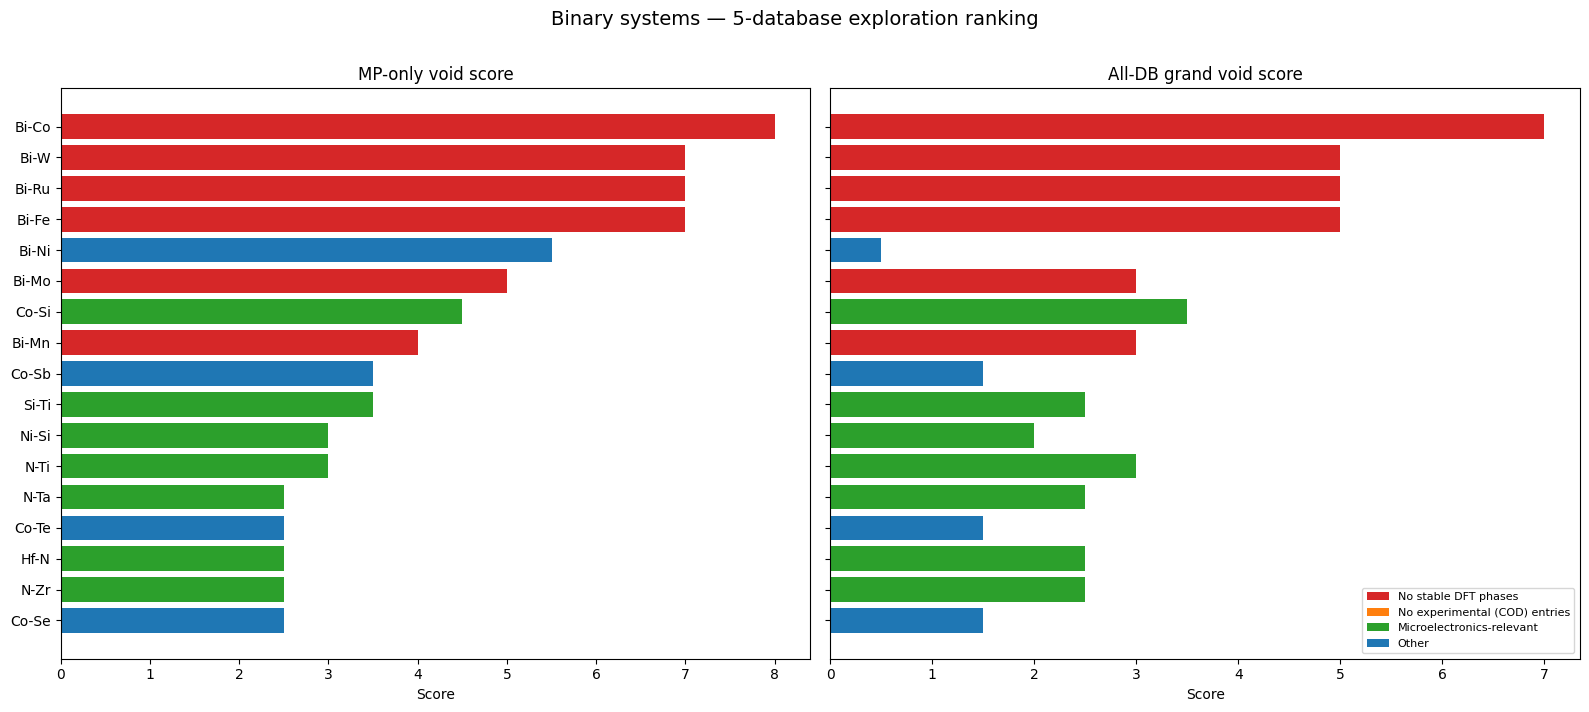

Plot saved to /home/hhoechter/projects/hullgap/outputs/grand_void_scores.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, score_col, title in [
    (axes[0], "void_score_adj", "MP-only void score"),
    (axes[1], "grand_void_score_adj", "All-DB grand void score"),
]:
    plot_df = df_merged.sort_values(score_col, ascending=True)
    colors = []
    for _, r in plot_df.iterrows():
        if r["dft_total_stable"] == 0:
            colors.append("#d62728")
        elif r["microelectronics_tag"]:
            colors.append("#2ca02c")
        elif not r["has_experimental"]:
            colors.append("#ff7f0e")
        else:
            colors.append("#1f77b4")
    ax.barh(plot_df["system"], plot_df[score_col], color=colors)
    ax.set_xlabel("Score")
    ax.set_title(title)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#d62728", label="No stable DFT phases"),
    Patch(facecolor="#ff7f0e", label="No experimental (COD) entries"),
    Patch(facecolor="#2ca02c", label="Microelectronics-relevant"),
    Patch(facecolor="#1f77b4", label="Other"),
]
axes[1].legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.suptitle("Binary systems — 5-database exploration ranking", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "grand_void_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved to {OUTPUT_DIR / 'grand_void_scores.png'}")

## 17. Save all outputs

In [24]:
for name, df in [
    ("aflow_binary_entries", df_aflow),
    ("jarvis_binary_entries", df_jarvis),
    ("nomad_binary_entries", df_nomad),
    ("cod_binary_entries", df_cod),
]:
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"  {path.name}: {len(df)} rows")

grand_path = OUTPUT_DIR / "grand_binary_survey.csv"
df_merged.to_csv(grand_path, index=False)
print(f"\n  {grand_path.name}: {len(df_merged)} systems (ranked)")
print(f"\nAll files in {OUTPUT_DIR}")

  aflow_binary_entries.csv: 3236 rows
  jarvis_binary_entries.csv: 131 rows
  nomad_binary_entries.csv: 11692 rows
  cod_binary_entries.csv: 98 rows

  grand_binary_survey.csv: 17 systems (ranked)

All files in /home/hhoechter/projects/hullgap/outputs


## Summary

This notebook queries **five** materials databases for 17 binary systems:

| Database | Type | API | Entries |
|----------|------|-----|---------|
| Materials Project | DFT | `mp-api` Python client | formation energy, hull distance |
| AFLOW | DFT | AFLUX REST | formation enthalpy, Pearson types |
| JARVIS-DFT | DFT | FigShare bulk download | formation energy, hull distance |
| NOMAD | Aggregator | REST v1 | origin-aware, prototypes |
| COD | Experimental | REST | experimentally synthesised structures |

### Output files

| File | Contents |
|------|----------|
| `mp_binary_survey.csv` | Per-system MP summary with MP-only void scores |
| `mp_binary_entries.csv` | All individual MP entries |
| `mp_binary_stable.csv` | Stable MP entries only |
| `aflow_binary_entries.csv` | All AFLOW entries |
| `jarvis_binary_entries.csv` | All JARVIS-DFT entries |
| `nomad_binary_entries.csv` | All NOMAD entries (with origin field) |
| `cod_binary_entries.csv` | All COD experimental entries |
| **`grand_binary_survey.csv`** | **Merged 5-DB summary with grand void scores** |

### Grand void score components

| Condition | Points |
|-----------|--------|
| 0 DFT entries (MP+AFLOW+JARVIS) | +4 |
| 1–10 DFT entries | +3 |
| 11–30 DFT entries | +2 |
| 31–60 DFT entries | +1 |
| 0 stable/neg-Hf phases | +3 |
| 1–2 stable/neg-Hf phases | +1.5 |
| ≤ 2 unique stoichiometries | +1 |
| No experimental COD entries | +1 |
| No unique NOMAD contributions | +0.5 |
| Microelectronics-relevant | +1 |
| +0.5 per neighbour system with stable phases | (bonus) |

**Next steps:**
1. Pick top-ranked systems (high `grand_void_score_adj`).
2. Use AFLOW Pearson types and NOMAD prototypes as structural templates.
3. Relax with MLIP (CHGNet / MACE) and score against the convex hull.
4. Validate the most promising candidates with DFT (Quantum ESPRESSO).

> **OQMD note:** OQMD's API has been returning 502 since April 2026.
> NOMAD indexes OQMD entries, so OQMD data is partially captured via NOMAD.
> If OQMD comes back, it can be added as a sixth source.